# set up

In [8]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [17]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")

In [10]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [11]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Baseline (no coupling)

In [39]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    # for j, input_probe in enumerate(probe_list):
    #     model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    # for j, input_probe in enumerate(probe_list):
    #     model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = aic

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [02:22, 23.75s/it]

AIC improvement of the model is: 0.0


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

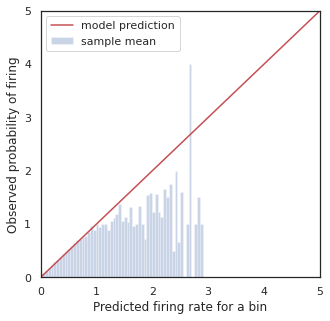

In [40]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# Only cross-area coupling

In [33]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if j == i:
            continue
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        if j == i:
            continue
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [02:34, 25.77s/it]

AIC improvement of the model is: 10042.636811195523


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

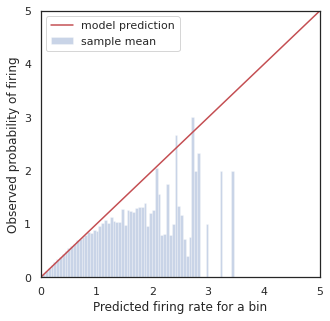

In [38]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# Both cross-area coupling and history

This is unstable when doing simulation

In [41]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [02:43, 27.31s/it]

AIC improvement of the model is: 12696.073275929317


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

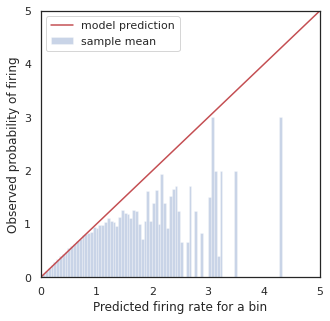

In [42]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# With interaction in history effect

In [43]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [02:49, 28.21s/it]

AIC improvement of the model is: 14843.503279722761


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

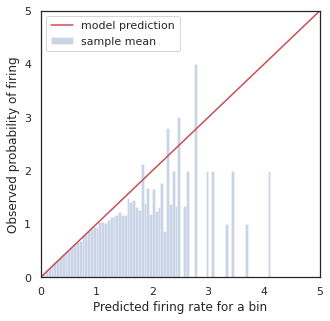

In [44]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# With only 2nd interaction in history effect

In [46]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
#                                 apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                                apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
#                              apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [02:48, 28.09s/it]

AIC improvement of the model is: 14361.008584019612


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

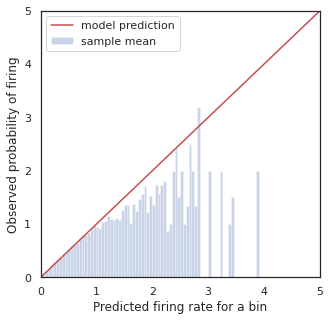

In [47]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# With both 1st and 2nd interaction in history effect

In [48]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
                                apply_no_penalty=True)
    model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                                apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [02:53, 28.92s/it]

AIC improvement of the model is: 15284.34384673636


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

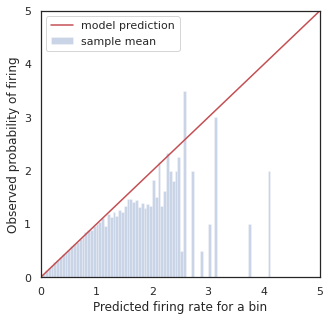

In [49]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# With $\Lambda$ in history effect

In [94]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [02:35, 25.89s/it]

AIC improvement of the model is: 12646.937623553793


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

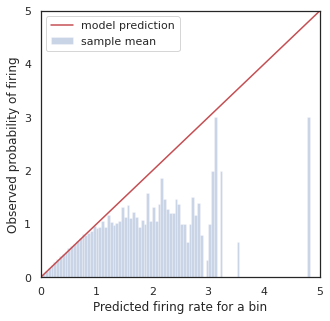

In [95]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

## Distribution of $\Lambda$

<AxesSubplot:ylabel='Count'>

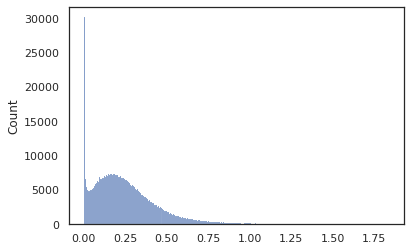

In [108]:
record_spike_density = []
for model in model_list:
    record_spike_density.append(model.effect_list[7].flatten('F'))
record_spike_density = np.hstack(record_spike_density)
sns.histplot(record_spike_density.flatten('F'))
# plt.xlim([-0.1, 1.5])

In [109]:
np.sum(record_spike_density>1)/len(record_spike_density)

0.0071627450980392155

In [105]:
np.sum(record_lmbd>1)/len(record_lmbd)

0.0128

In [110]:
record_lmbd = []
for model in model_list:
    record_lmbd.append(np.exp(model.log_lmbd).flatten('F'))
record_lmbd = np.hstack(record_lmbd)

<AxesSubplot:ylabel='Count'>

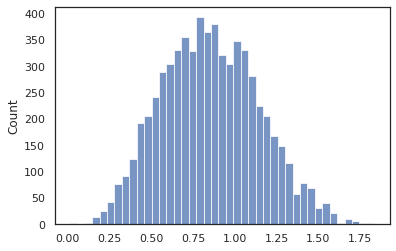

In [111]:
sns.histplot(record_spike_density[record_lmbd>1])

It seems like those uncalibrated cases (firing rate>1) are pretty much all those cases with unusual spike density

# With $\Lambda^2$ refractory in history effect

In [73]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [02:38, 26.49s/it]

AIC improvement of the model is: 14046.563964011031


In [77]:
model.basis_name[7]

'refractory'

/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

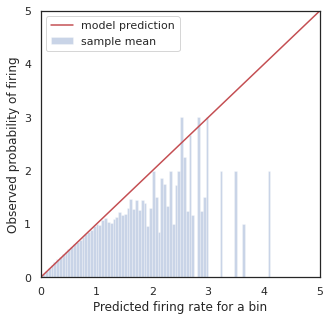

In [74]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# With $\Lambda^{1.5}$ refractory in history effect

In [54]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [02:36, 26.13s/it]

AIC improvement of the model is: 14638.256871828693


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

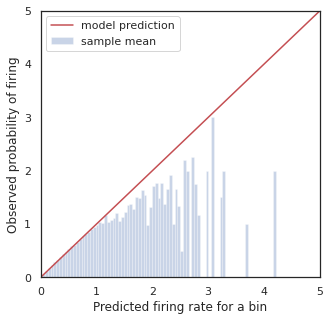

In [55]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# Interaction in all coupling effects

Not so good

In [56]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_stationary.add_effect('interaction', probe_list[j], tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_running.add_effect('interaction', probe_list[j], tau=tau, **coupling_filter_params, apply_no_penalty=True)
    # model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [03:08, 31.40s/it]

AIC improvement of the model is: 15553.783042540308


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

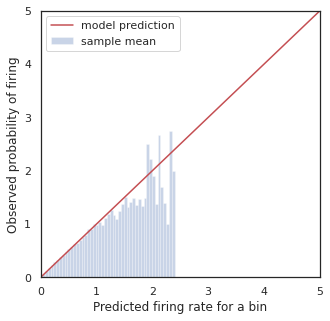

In [57]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# $\Lambda^2$ in all coupling effects

bad

In [71]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_stationary.add_effect('refractory', probe_list[j], tau=tau, order=1.5, **coupling_filter_params, 
                                    apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
        model_running.add_effect('refractory', probe_list[j], tau=tau, order=1.5, **coupling_filter_params, 
                                    apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [03:01, 30.28s/it]

AIC improvement of the model is: 15427.673777929507


/tmp/ipykernel_23266/829749624.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


(0.0, 5.0)

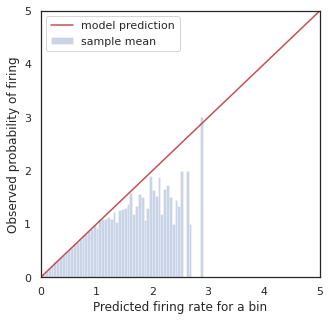

In [72]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

# refractory nonparametric

In [12]:
ihbasis.shape

(158, 10)

In [112]:
interpolate_token

[array([   0.,    0.,    0.,  125.,  250.,  375.,  500.,  625.,  750.,
         875., 1000., 1000., 1000.]),
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1.0],
 2]

In [175]:
import scipy
num_basis=10
t_max=1000
t_min=0
add_constant_basis=False
dt=1
spline_order=2
verbose=False

num_knots = num_basis-spline_order+1
knots = np.linspace(t_min, t_max, num_knots)
knots = np.hstack((np.ones(2) * t_min, 
                    knots,
                    np.ones(2) * t_max))

num_basis = len(knots) - spline_order - 1
num_rows = int(np.round((knots[-1] - knots[0]) / dt))
t = np.linspace(knots[0]-500, knots[-1]+500, num_rows)
basis_matrix = np.zeros((len(t), num_basis))
interpolate_token=[0, 0, spline_order]
interpolate_token[0] = np.array(knots)

for i in range(num_basis):
    basis_coefficients = [0] * num_basis
    basis_coefficients[i] = 1.0 
    interpolate_token[1] = basis_coefficients
    y = scipy.interpolate.splev(t, interpolate_token)
    basis_matrix[:, i] = y
    
# max_scale = np.max(basis_matrix,axis=0)
# basis_matrix = basis_matrix/max_scale


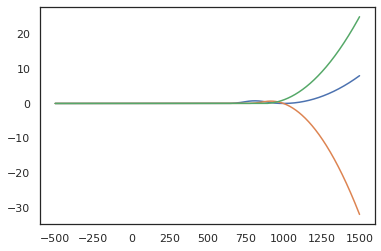

In [176]:
plt.plot(t, basis_matrix[:,7])
plt.plot(t, basis_matrix[:,8])
plt.plot(t, basis_matrix[:,9])

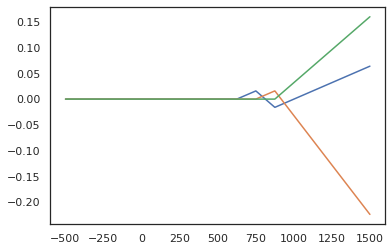

In [177]:
plt.plot(t[1:], np.diff(basis_matrix[:,7]))
plt.plot(t[1:], np.diff(basis_matrix[:,8]))
plt.plot(t[1:], np.diff(basis_matrix[:,9]))

In [181]:
record_spike_density.shape

(510000,)

In [218]:
from patsy import cr
from patsy import bs
xx = np.linspace(0, 1.75, 500)
# x_basis = cr(xx, knots=[0.3,0.6,0.9,1.2])
x_basis = cr(xx, df=20)
# x_basis = bs(xx, df=20)

In [219]:
x_basis.shape

(500, 20)

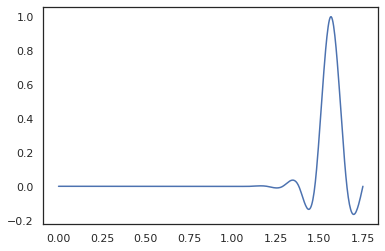

In [225]:
plt.plot(xx, x_basis[:,17])

# Final chosen model

In [997]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', probe_list[j], tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', probe_list[j], tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8811.665204589794


# Fit six areas with 14 conditions

## Set up

In [114]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [115]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Decide couping filter hyperparameters

After many tries, the best hyperparameters for coupling filter is 
peaks_max=50, num=6, nonlinear=0.3

In [389]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_stationary.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model_running.add_effect('trial_coef')
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter)

print(model_running.aic + model_stationary.aic)

56529.698990358615


## Fit

In [128]:
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
#     model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    running_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_output[i,j] = filter_list[k]
        k += 1
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
#     model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
#     model.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    filter_list = model.get_filter_output(ci=True)
    stationary_output[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_output[i,j] = filter_list[k]
        k += 1
    
    # for effect filter
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    ROI_filter_left[filter_index], statistics_filter_left[filter_index] = \
        GLM.get_excursion_statistic(function1, function2, time_range=[0, 40])
    ROI_filter_right[filter_index], statistics_filter_right[filter_index] = \
        GLM.get_excursion_statistic(function1, function2, time_range=[40, 100])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    
    # for effect output
    filter_index = i,-1
    function1 = np.exp( running_output[filter_index][0] )
    function2 = np.exp( stationary_output[filter_index][0] )
    ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)
    ROI_output_left[filter_index], statistics_output_left[filter_index] = \
        GLM.get_excursion_statistic(function1, function2, time_range=[0, 200])
    ROI_output_right[filter_index], statistics_output_right[filter_index] = \
        GLM.get_excursion_statistic(function1, function2, time_range=[200, 400])
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_output[filter_index][0]
        function2 = stationary_output[filter_index][0]
        ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)


6it [03:16, 32.77s/it]


In [103]:
total_nll = sum([running_model_list[i].aic for i in range(6)]) + sum([stationary_model_list[i].aic for i in range(6)])
print(f"likelihood: {total_nll}")

likelihood: 283753.0318527139


In [166]:
fix_peak_time = []
for i_probe in range(6):
    fix_peak_time_single = np.zeros((V1.ntrial, 4))
    fix_peak_time_single[:,0] = (stationary_model_list[i_probe].shifts[0,0] + running_model_list[i_probe].shifts[0,0])/2
    fix_peak_time_single[:,2] = (stationary_model_list[i_probe].shifts[0,2] + running_model_list[i_probe].shifts[0,2])/2
    i_stationary = 0
    i_running = 0
    for itrial in range(V1.ntrial):
        if stationary_model_list[0].select_trials[itrial] == True:
            fix_peak_time_single[itrial, 1] = stationary_model_list[i_probe].shifts[i_stationary,1]
            fix_peak_time_single[itrial, 3] = stationary_model_list[i_probe].shifts[i_stationary,3]
            i_stationary += 1
        else:
            fix_peak_time_single[itrial, 1] = running_model_list[i_probe].shifts[i_running,1]
            fix_peak_time_single[itrial, 3] = running_model_list[i_probe].shifts[i_running,3]
            i_running += 1
    fix_peak_time.append(fix_peak_time_single)

## Random shuffle (Excursion test)

In [206]:
from GLM import get_statistics_null_mp
statistics_null_filter_new, statistics_null_output_new = get_statistics_null_mp(4000, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params, fix_peak_time=fix_peak_time)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=5


100%|██████████████████████████████| 4000/4000 [6:06:23<00:00,  5.50s/it]


In [202]:
# Initialize
statistics_null_filter = statistics_null_filter_new
statistics_null_output = statistics_null_output_new

In [119]:
# Load
with open('statistics_null_filter.pickle', 'rb') as handle:
    statistics_null_filter = pickle.load(handle)
with open('statistics_null_output.pickle', 'rb') as handle:
    statistics_null_output = pickle.load(handle)

# with open('statistics_null_filter_nowarping.pickle', 'rb') as handle:
#     statistics_null_filter = pickle.load(handle)
# with open('statistics_null_output_nowarping.pickle', 'rb') as handle:
#     statistics_null_output = pickle.load(handle)

# with open('statistics_null_filter_nowarping_two.pickle', 'rb') as handle:
#     statistics_null_filter = pickle.load(handle)
# with open('statistics_null_output_nowarping_two.pickle', 'rb') as handle:
#     statistics_null_output = pickle.load(handle)

In [192]:
# Merge new generated samples with the old ones
statistics_null_filter = GLM.merge_dict(statistics_null_filter, statistics_null_filter_new)
statistics_null_output = GLM.merge_dict(statistics_null_output, statistics_null_output_new)

In [120]:
# Save statistics_null_filter and statistics_null_output
with open('statistics_null_filter.pickle', 'wb') as handle:
    pickle.dump(statistics_null_filter, handle)
with open('statistics_null_output.pickle', 'wb') as handle:
    pickle.dump(statistics_null_output, handle)

# with open('statistics_null_filter_nowarping.pickle', 'wb') as handle:
#     pickle.dump(statistics_null_filter, handle)
# with open('statistics_null_output_nowarping.pickle', 'wb') as handle:
#     pickle.dump(statistics_null_output, handle)

# with open('statistics_null_filter_nowarping_two.pickle', 'wb') as handle:
#     pickle.dump(statistics_null_filter, handle)
# with open('statistics_null_output_nowarping_two.pickle', 'wb') as handle:
#     pickle.dump(statistics_null_output, handle)

In [203]:
np.sum( statistics_null_filter[0,5] > statistics_filter[0,5] ), len( statistics_null_filter[0,5] )

(0, 5000)

In [204]:
np.sum( statistics_null_filter[3,2] > statistics_filter[3,2] ), len( statistics_null_filter[0,5] )

(0, 5000)

In [ ]:
np.sum( statistics_null_filter[3,2] > statistics_filter[3,2] ), len( statistics_null_filter[0,5] )

# Filters and inference on filters

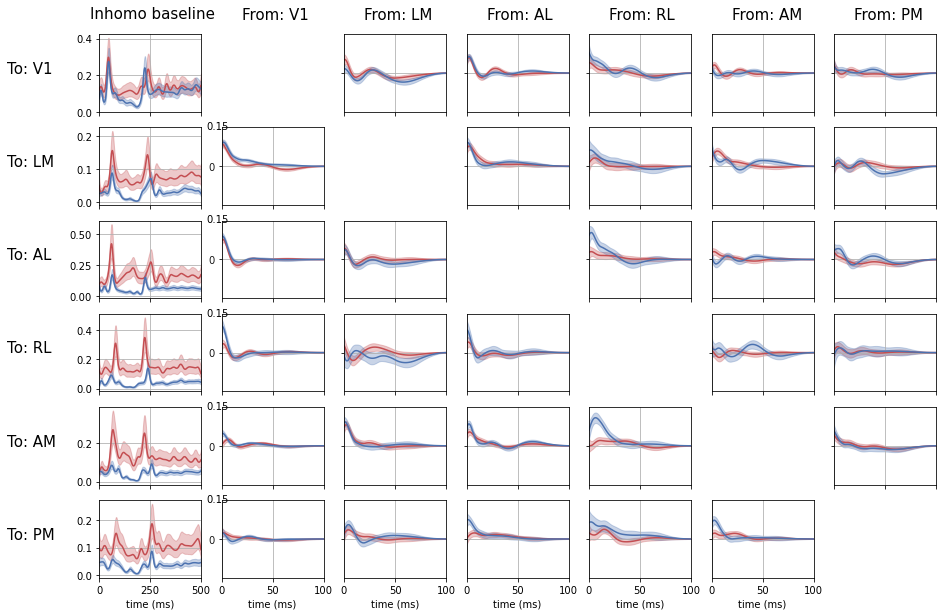

In [117]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False)

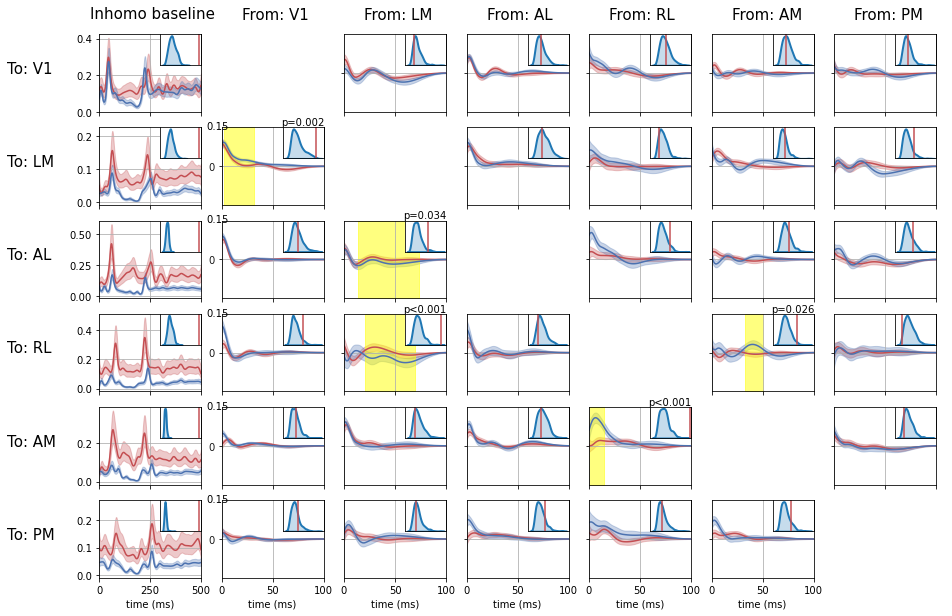

In [121]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, 
                                statistics_filter=statistics_filter, 
                                statistics_null_filter=statistics_null_filter, 
                                ROI_filter=ROI_filter,
#                                inference=False
                              )

# Output and inference on output

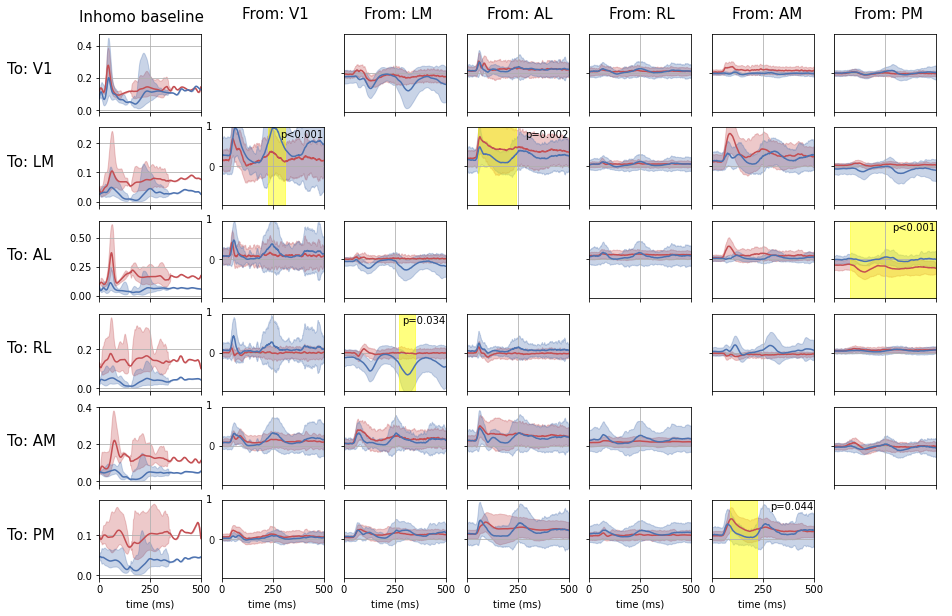

In [129]:
GLM.plot_output_with_excursion(V1, stationary_output, running_output, 
                                statistics_output=statistics_output, 
                                statistics_null_output=statistics_null_output, 
                                ROI_output=ROI_output, 
#                               inference=False
                              )

# Plot all effect's output in an example trial

In [50]:
stationary_model_list[3].basis_name

['time_warping_inhomogeneous_baseline',
 'coupling from AM',
 'coupling from PM',
 'coupling from V1',
 'coupling from LM',
 'coupling from AL',
 'coupling from RL',
 'interaction from V1',
 'trial_coef']

In [51]:
to_look_at = 3
import copy
outputs = [stationary_model_list[to_look_at].get_filter_output(ci=False)[i] for i in range(9)]
outputs[to_look_at+1] += outputs[7]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 8):
    total_output += outputs[i]

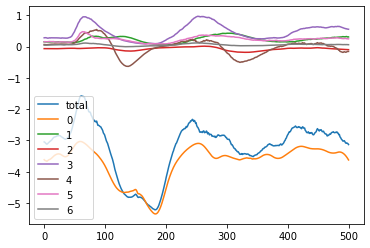

In [52]:
plt.plot(total_output, label='total')
for i, output in enumerate(outputs[:7]):
    plt.plot( output ,label=str(i))
plt.legend()

In [89]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]


In [92]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(10)]
outputs[to_look_at+1] += outputs[7] + outputs[8]
outputs[0] += outputs[9]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]


Text(0.5, 0, 'time (ms)')

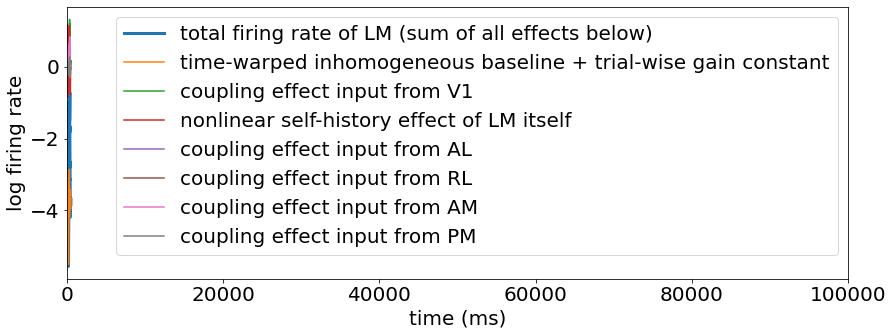

In [93]:
sns.reset_orig()
trial = 1
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(14,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.legend(['total firing rate of LM (sum of all effects below)', 
            'time-warped inhomogeneous baseline + trial-wise gain constant', 
            'coupling effect input from V1', 
            'nonlinear self-history effect of LM itself', 
            'coupling effect input from AL',
            'coupling effect input from RL',
            'coupling effect input from AM',
            'coupling effect input from PM'], fontsize=fontsize)
plt.xlim([-30, 100000])
plt.ylabel('log firing rate', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

Text(0.5, 0, 'time (ms)')

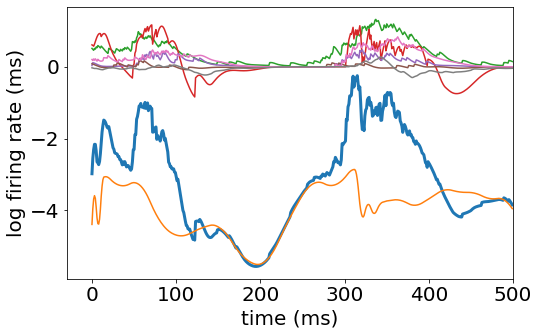

In [98]:
sns.reset_orig()
trial = 1
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

# Simulation

## Use lambda varying post-spike filters to simulate

Use stationary model list and running model list to do simulation

In [8]:
# Fit
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)


6it [04:01, 40.22s/it]


In [19]:
###################
nepoch = 10
model_list = stationary_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_stationary = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in range(nepoch):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_mat = np.zeros((max_histories_refractory, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

                elif effect_type in ['interaction']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories_refractory:
                        refractory_mat_old = refractory_mat
                        refractory_mat = np.zeros((nhistories, nneuron, nneuron))
                        refractory_mat[-max_histories_refractory:, :, :] = refractory_mat_old
                        max_histories_refractory = nhistories
                    refractory_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect]) 

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (refractory_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory *= recent_spike_sum/tau
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_stationary[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_stationary[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

In [20]:
###################
nepoch = 10
model_list = running_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_running = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in range(nepoch):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_mat = np.zeros((max_histories_refractory, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

                elif effect_type in ['interaction']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories_refractory:
                        refractory_mat_old = refractory_mat
                        refractory_mat = np.zeros((nhistories, nneuron, nneuron))
                        refractory_mat[-max_histories_refractory:, :, :] = refractory_mat_old
                        max_histories_refractory = nhistories
                    refractory_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect]) 

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (refractory_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory *= recent_spike_sum/tau
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_running[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_running[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

### PSTH compare

#### Experimental PSTH

Text(0.5, 1.0, 'Experimental average firing rate across trials (resting condition)')

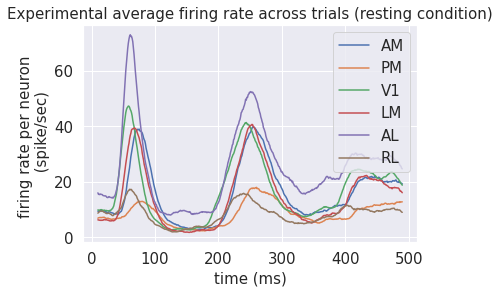

In [16]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']

fontsize = 15
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(stationary_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Experimental average firing rate across trials (running condition)')

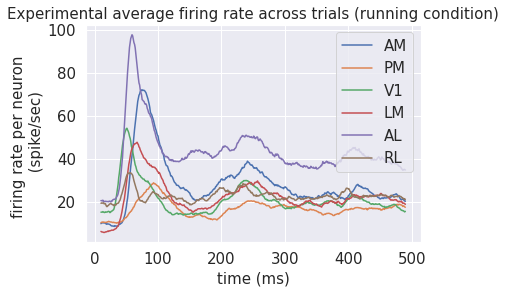

In [17]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(running_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (running condition)', fontsize=fontsize)

#### Simulated PSTH

Text(0.5, 1.0, 'Simulated average firing rate across trials (resting condition)')

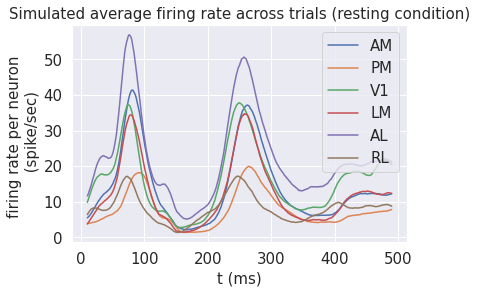

In [21]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_stationary[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Simulated average firing rate across trials (running condition)')

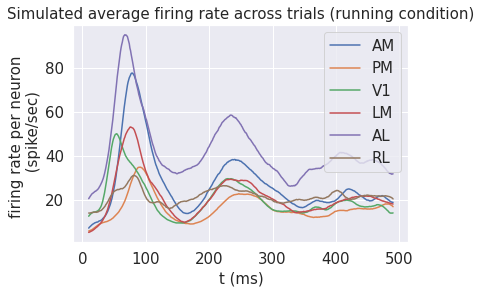

In [22]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_running[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (running condition)', fontsize=fontsize)

### Single trial plot

Text(0.5, 1.0, 'Stationary condition')

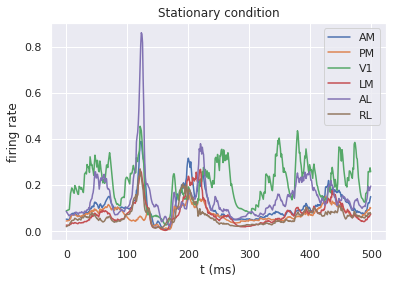

In [36]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate_rcd_stationary[:,itrial, i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Stationary condition')

Text(0.5, 1.0, 'Running condition')

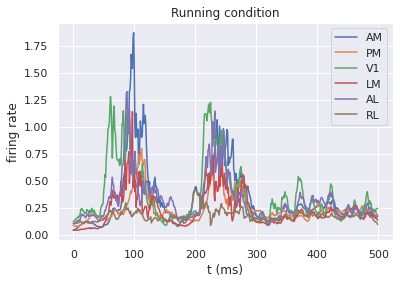

In [28]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate_rcd_running[:,itrial, i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Running condition')

Text(0.5, 1.0, 'Experimental; Stationary condition')

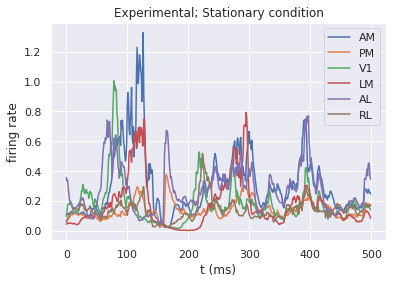

In [44]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(stationary_model_list[i].log_lmbd[:,itrial]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Experimental; Stationary condition')

Text(0.5, 1.0, 'Experimental; Running condition')

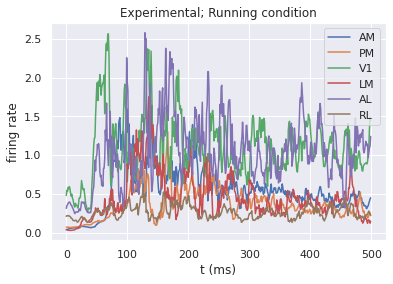

In [43]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(running_model_list[i].log_lmbd[:,itrial]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Experimental; Running condition')

## Use Lambda^2 as a coefficient to simulate

In [32]:
# Fit
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)


6it [03:34, 35.75s/it]


In [33]:
# Stationary model simulation
nepoch = 10
model_list = stationary_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_stationary = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in tqdm( range(nepoch) ):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction', 'refractory']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_params = np.zeros(nneuron)
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                    baseline_mat[:, ineuron] += model.results.params[67+itrial]
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

            refractory_params[ineuron] = model.results.params[66]
        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (recent_spike_sum/tau)**2
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory*refractory_params
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_stationary[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_stationary[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

100%|████████████████████████████████████| 10/10 [00:27<00:00,  2.79s/it]


In [34]:
# Running model simulation
nepoch = 10
model_list = running_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_running = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in tqdm( range(nepoch) ):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction', 'refractory']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_params = np.zeros(nneuron)
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                    baseline_mat[:, ineuron] += model.results.params[67+itrial]
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

            refractory_params[ineuron] = model.results.params[66]
        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (recent_spike_sum/tau)**2
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory*refractory_params
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_running[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_running[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

100%|████████████████████████████████████| 10/10 [00:17<00:00,  1.75s/it]


### PSTH compare

#### Experimental PSTH

Text(0.5, 1.0, 'Experimental average firing rate across trials (resting condition)')

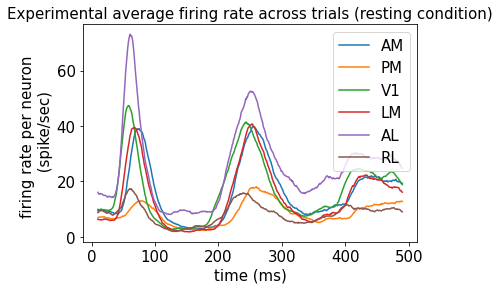

In [35]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']

fontsize = 15
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(stationary_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Experimental average firing rate across trials (running condition)')

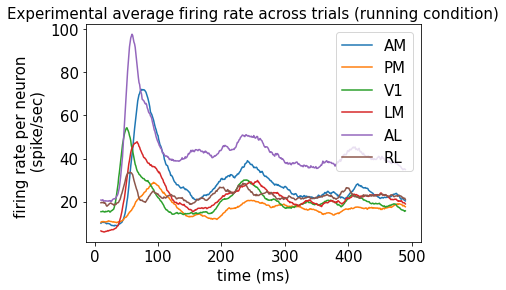

In [36]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(running_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (running condition)', fontsize=fontsize)

#### Simulated PSTH

Text(0.5, 1.0, 'Simulated average firing rate across trials (resting condition)')

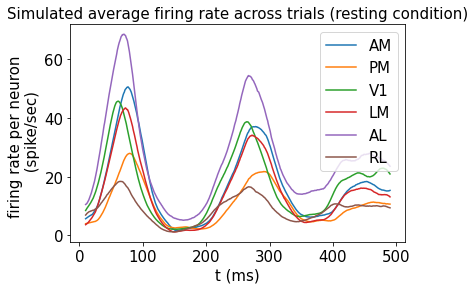

In [37]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_stationary[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Simulated average firing rate across trials (running condition)')

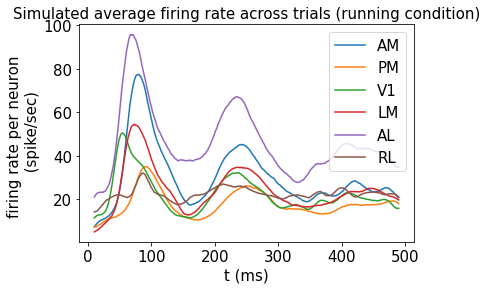

In [38]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_running[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (running condition)', fontsize=fontsize)

### Single trial plot

Text(0.5, 1.0, 'Stationary condition')

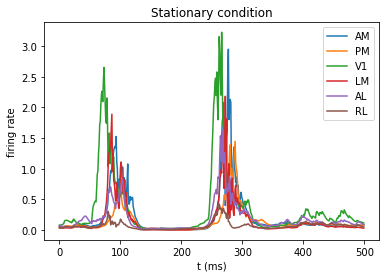

In [729]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Stationary condition')

Text(0.5, 1.0, 'Running condition')

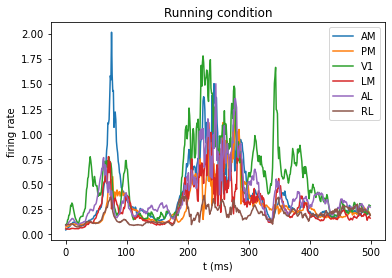

In [736]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Running condition')

## Correlation and partial correlation

In [473]:
peaks_rcd = np.concatenate((peaks_rcd_stationary, peaks_rcd_running), axis=1)
peaks_rcd.shape

(2, 2100, 6)

In [474]:
GLM.corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.56112903, 0.63137318],
       [0.56112903, 1.        , 0.54067431],
       [0.63137318, 0.54067431, 1.        ]])

In [475]:
GLM.partial_corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.40691691, 0.53989767],
       [0.40691691, 1.        , 0.39778186],
       [0.53989767, 0.39778186, 1.        ]])

In [493]:
model_list = stationary_model_list
peaks_rcd_stationary = np.zeros((2, model_list[0].ntrial, len(model_list)))
for itrial in range(model_list[0].ntrial):
    for ineuron in range(len(model_list)):
        peaks_rcd_stationary[1, itrial, ineuron] = \
            np.nanargmax(utils.kernel_smoothing(np.exp(model_list[ineuron].log_lmbd[150:, itrial])[:, np.newaxis], std=1))

model_list = running_model_list
peaks_rcd_running = np.zeros((2, model_list[0].ntrial, len(model_list)))
for itrial in range(model_list[0].ntrial):
    for ineuron in range(len(model_list)):
        peaks_rcd_running[1, itrial, ineuron] = \
            np.nanargmax(utils.kernel_smoothing(np.exp(model_list[ineuron].log_lmbd[150:, itrial])[:, np.newaxis], std=1))
        

In [494]:
peaks_rcd = np.concatenate((peaks_rcd_stationary, peaks_rcd_running), axis=1)
peaks_rcd.shape

(2, 210, 6)

In [495]:
GLM.corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.32526144, 0.27682891],
       [0.32526144, 1.        , 0.41103366],
       [0.27682891, 0.41103366, 1.        ]])

In [496]:
GLM.partial_corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.3981565 , 0.29935124],
       [0.3981565 , 1.        , 0.50616431],
       [0.29935124, 0.50616431, 1.        ]])

In [806]:
running_model_list[0].effect_type_list

['inhomogeneous_baseline',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'refractory']